## 1: Przygotowanie danych do modelowanie

Import bibliotek i wczytanie danych

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("water_potability.csv")
df = df.replace('#NUM!', np.nan)
df = df.apply(pd.to_numeric, errors='coerce')
df.columns = df.columns.str.lower()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [17]:
df = df.dropna(subset=["is_safe"])
X = df.drop("is_safe", axis=1) #Podzial na cechy i zmienną docelową
y = df["is_safe"]
imputer = SimpleImputer(strategy="median") #Uzupełnianie braków danych (Braki danych zostały uzupełnione medianą, co jest odporne na wartości odstające.)
X = imputer.fit_transform(X)

W zbiorze danych wykryto braki w zmiennej is_safe. Ponieważ brak wartości docelowej uniemożliwia prawidłowe przeprowadzenie uczenia się z kontrolą, zapisy te zostały usunięte przed podziałem danych na zbiory szkoleniowe i testowe.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(  #Podział na zbiór treningowy i testowy
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
scaler = StandardScaler() #Skalowanie
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 2: Wybór typu modelu

Zmienna docelowa is_safe jest zmienną binarną, więc zadanie będzie polegało na klasyfikacji. Do rozwiązania zadania wybrałem MLP.

## 3: Trenowanie modelu

In [19]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


## 4: Ocena działania modelu

Predykcja

In [20]:
y_pred = model.predict(X_test)

Raport klasyfikacji

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97      1418
         1.0       0.77      0.75      0.76       182

    accuracy                           0.95      1600
   macro avg       0.87      0.86      0.87      1600
weighted avg       0.95      0.95      0.95      1600



Macierz pomyłek

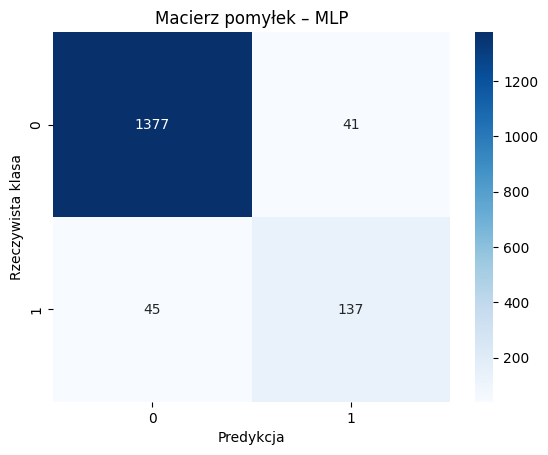

In [22]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywista klasa")
plt.title("Macierz pomyłek – MLP")
plt.show()

## 5: Wizualizacja wyników

Ważność cech

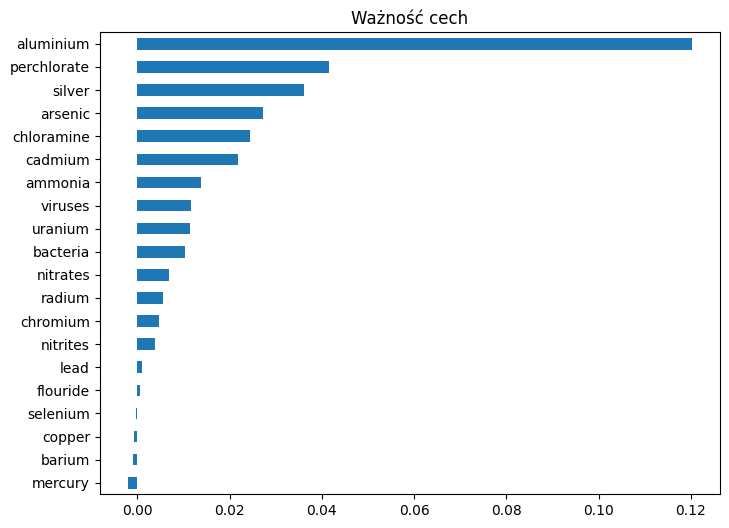

In [23]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=42
)

importances = pd.Series(result.importances_mean, index=df.columns.drop("is_safe"))
importances.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Ważność cech")
plt.show()

## 6: Podsumovanie modelu

Sieć neuronowa wykazała umiarkowaną skuteczność w klasyfikacji jakości wody. Analiza wskaźników jakości pokazuje, że model lepiej rozpoznaje jedną z klas.

Do mocnych stron modelu należy zdolność do modelowania nieliniowych zależności między charakterystykami. Ograniczeniami są wrażliwość na jakość danych i brak interpretowalności.